In [1]:
from hydromt.readers import read_workflow_yaml
from hydromt_sfincs import SfincsModel

In [2]:
fn_config = r"C:\PhD\SFINCS\SFINCS_cloned\hydromt_sfincs\examples\sfincs_base_update.yml"

In [3]:
modeltype, kwargs, steps = read_workflow_yaml(fn_config, modeltype="sfincs")


In [10]:
steps[0]

{'observation_points.create': {'locations': WindowsPath('C:/PhD/SFINCS/SFINCS_cloned/hydromt_sfincs/examples/data/compound_example_observation_points.geojson')}}

In [ ]:
mod = SfincsModel(root=r"C:\PhD\SFINCS\output\sfinxcs_620947", mode="r"
                  )
mod.update(steps=steps)

In [11]:
from hydromt.readers import read_yaml

In [17]:
test = read_yaml(r"C:\PhD\SFINCS\SFINCS_cloned\hydromt_sfincs\delta_model\code\scenarios.yml")
test

{'global': {'data_libs': ['data_catalog_v1']},
 'scenarios': {'baseline': ['use this to plot the baselines and find where to make restart file'],
  'river_flood': {'steps': [{'config.update': {'rsrtfile': 'C:/PhD/SFINCS/output/sfincs_620947/sfincs.20181209.000000.rst'}},
    {'discharge_points.create_timeseries': {'index': [0],
      'shape': 'gaussian',
      'peak': 700,
      'timestep': 600}}]},
  'storm_surge': [{'config.update': {'rsrtfile': 'C:/PhD/SFINCS/output/sfincs_620947/sfincs.20181209.000000.rst'}},
   {'water_level.create_timeseries': {'shape': 'gaussian',
     'timestep': 600,
     'offset': 0.5,
     'peak': 3}}]}}

In [27]:
scenarios = test["scenarios"].keys()

In [28]:
scenarios

dict_keys(['baseline', 'river_flood', 'storm_surge'])

In [31]:
scenario_1 = test["scenarios"]["river_flood"]
steps_1 = scenario_1["steps"]
steps_1

[{'config.update': {'rsrtfile': 'C:/PhD/SFINCS/output/sfincs_620947/sfincs.20181209.000000.rst'}},
 {'discharge_points.create_timeseries': {'index': [0],
   'shape': 'gaussian',
   'peak': 700,
   'timestep': 600}}]

In [ ]:
# baseline_root = ...
# for scenario in scenarios:
#     new_root = ...
#     steps = test["scenarios"][scenario]["steps"]

#     # First read the model
#     mod = SfincsModel(root=baseline_root, mode="r")
#     mod.read()

#     # Now change the root of the model
#     mod.root.set(new_root, mode="w+")

#     # Now update the model
#     # mod.update(steps=steps_1)

#     mod.config.update(**steps["config.update"])
#     mod.discharge_points.create_timeseries(**steps["discharge_points.create_timeseries"])

## more automatic river building 

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# 1. Load data
delta_domain = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\4_delta_polygons.geojson")
delta_domain = delta_domain[delta_domain['BasinID2'] == 620947].to_crs(epsg=3857)

rivers_sword = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\SWORD_global_unpublished.gpkg", mask=delta_domain).to_crs(epsg=3857)
rivers_lin = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\rivers_lin.gpkg", mask=delta_domain).to_crs(epsg=3857)

# 2. Map boundary inflows
boundary_line = delta_domain.geometry.boundary.iloc[0]
inflow_reaches = rivers_sword[rivers_sword.intersects(boundary_line)].copy()
joined_inflows = gpd.sjoin_nearest(inflow_reaches, rivers_lin, max_distance=100, how='inner')
rivers_sword['inflow_Q2'] = rivers_sword['reach_id'].map(dict(zip(joined_inflows['reach_id'], joined_inflows['Q2']))).fillna(0)

# 3. Create Connection Map
tail_circles = rivers_sword.copy()
tail_circles['geometry'] = tail_circles.geometry.apply(lambda x: Point(x.coords[-1])).buffer(150)
head_points = rivers_sword.copy()
head_points['geometry'] = head_points.geometry.apply(lambda x: Point(x.coords[0]))

# Spatial join to find connections
connections = gpd.sjoin(head_points[['reach_id', 'geometry']], tail_circles[['reach_id', 'geometry']], how='inner', predicate='within')
# Drop geometry and convert to simple DataFrame for the connection map
conn_map = pd.DataFrame(connections[['reach_id_left', 'reach_id_right']])
conn_map = conn_map[conn_map['reach_id_left'] != conn_map['reach_id_right']].astype(int)
conn_map = conn_map.rename(columns={'reach_id_left': 'down_id', 'reach_id_right': 'up_id'})

# 4. Flow Accumulation (Waterfall)
q_dict = rivers_sword.set_index('reach_id')['inflow_Q2'].to_dict()
is_boundary = rivers_sword.set_index('reach_id')['inflow_Q2'] > 0
widths = rivers_sword.set_index('reach_id')['width'].to_dict()

for _ in range(100):
    next_q = {rid: val for rid, val in q_dict.items() if is_boundary.get(rid, False)}
    for up_id, group in conn_map.groupby('up_id'):
        parent_flow = q_dict.get(up_id, 0)
        if parent_flow <= 0: continue
        
        down_ids = group['down_id'].unique()
        total_w = sum(widths.get(d_id, 0) for d_id in down_ids)
        for d_id in down_ids:
            if not is_boundary.get(d_id, False):
                share = widths.get(d_id, 0) / total_w if total_w > 0 else (1.0 / len(down_ids))
                next_q[d_id] = next_q.get(d_id, 0) + (parent_flow * share)
    q_dict.update(next_q)

# rename width variable to match sfincs requirements
rivers_sword = rivers_sword.rename(columns={'width': 'rivwth'})

# Calculate depth of river segments 
rivers_sword['final_Q2'] = rivers_sword['reach_id'].map(q_dict).fillna(0)
rivers_clipped = rivers_sword[rivers_sword['final_Q2'] > 1e-4].copy()

a = 0.27
b = 0.30
rivers_clipped['rivdph'] = (a * (rivers_clipped['final_Q2']**b)).clip(lower=0.1)


print(rivers_clipped[['reach_id', 'final_Q2', 'rivwth', 'rivdph']].head())

      reach_id    final_Q2  rivwth    rivdph
0  56275600021  322.661091   216.0  1.527523
1  56275600013  322.661091   366.0  1.527523
2  56275500016  322.661091   351.0  1.527523


In [3]:
rivers_clipped.to_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\sfincs_test_aus.geojson", driver='GeoJSON')


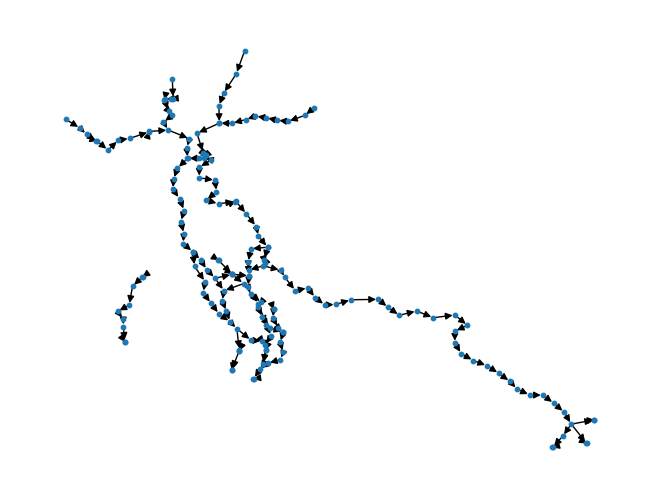

In [23]:
# # river connectivity with SWORD to calculate Q2 down the river and then determine depth 
# # (1) Create a directed graph from the SWORD dataset

# import networkx as nx
# import pandas as pd
# import numpy as np

# # Create the Directed Graph
# G = nx.DiGraph()

# # Add edges. We use the start/end points of the lines as node identifiers.
# for idx, row in sword.iterrows():
#     coords = list(row.geometry.coords)
#     # We round the coordinates to avoid precision issues (e.g., 0.000001m gaps)
#     start_pt = tuple(np.round(coords[0], 2)) 
#     end_pt = tuple(np.round(coords[-1], 2))
    
#     G.add_edge(start_pt, end_pt, 
#                reach_id=row['reach_id'], 
#                width=row['width'], 
#                pos=row['path_seg_pos'],
#                Q=row.get('inflow_Q2', 0))

# # plot the graph to check connectivity
# import matplotlib.pyplot as plt
# pos = {node: (node[0], node[1]) for node in G.nodes()}
# nx.draw(G, pos, node_size=10, with_labels=False)
# plt.show()



## step by step process of river stuff 

In [ ]:
# Only keeps Q2 at entry domain into model 
import geopandas as gpd
from tqdm import tqdm

# 1. Load data
target_basin = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\4_delta_polygons.geojson")
target_basin = target_basin[target_basin['BasinID2'] == 4267691].to_crs(epsg=3857)
sword = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\SWORD_global_unpublished.gpkg", mask=target_basin).to_crs(epsg=3857)
lin_points = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\rivers_lin.gpkg", mask=target_basin).to_crs(epsg=3857)

# 2. Find where SWORD intersects the boundary (The Inflow/Outflow points)
boundary_line = target_basin.geometry.boundary.iloc[0]
sword['intersects_boundary'] = sword.intersects(boundary_line)
inflow_reaches = sword[sword['intersects_boundary']].copy()

# 3. Join Lin Q2 to these specific boundary reaches
# We use a constrained join: closest point within 1km
joined_inflows = gpd.sjoin_nearest(inflow_reaches, 
                                   lin_points, 
                                   max_distance=100, 
                                   how='inner')

# 4. Create a lookup for the boundary reaches
q2_boundary_map = dict(zip(joined_inflows['reach_id'], joined_inflows['Q2']))

# 5. Apply back to your SWORD dataset
sword['inflow_Q2'] = sword['reach_id'].map(q2_boundary_map)

print(f"Assigned Q2 to {len(q2_boundary_map)} boundary reaches.")

print(sword[['reach_id', 'inflow_Q2', 'width']].dropna())

import geopandas as gpd
from shapely.geometry import Point


In [102]:
import geopandas as gpd
from shapely.geometry import Point

# 1. Capture EVERY segment's END point (Potential Upstream Source)
# We don't filter by pos here—if it ends, it can feed a bifurcation
tails = sword.copy()
tails['geometry'] = tails.geometry.apply(lambda x: Point(x.coords[-1]))
tail_circles = tails.copy()
tail_circles['geometry'] = tail_circles.buffer(150)

# 2. Capture EVERY segment's START point (Potential Downstream Receiver)
# Especially those pesky '0' segments in a cluster
heads = sword.copy()
heads['geometry'] = heads.geometry.apply(lambda x: Point(x.coords[0]))
head_circles = heads.copy()
head_circles['geometry'] = head_circles.buffer(150)

# 3. Export for QGIS
tail_circles.to_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\DEBUG_all_tails.geojson", driver='GeoJSON')
head_circles.to_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\DEBUG_all_heads.geojson", driver='GeoJSON')

print("Files exported. Now, even '0-to-0' segments will show their connections.")

Files exported. Now, even '0-to-0' segments will show their connections.


In [103]:
# Create head points (without the 100m buffer) for a clean intersection
head_points = heads.copy() 
head_points['geometry'] = sword.geometry.apply(lambda x: Point(x.coords[0]))

# 1. Spatial Join: Find which heads are 'within' which tail circles
# reach_id_left = Downstream (Head), reach_id_right = Upstream (Tail)
connections = gpd.sjoin(head_points, tail_circles[['reach_id', 'geometry']], how='inner', predicate='within')

# 2. Create the conn_map table
conn_map = connections[['reach_id_left', 'reach_id_right']].rename(columns={
    'reach_id_left': 'downstream_id',
    'reach_id_right': 'upstream_id'
})

# 3. CRITICAL: Remove self-joins
# (A segment's own start point will always be within its own end-point buffer if the segment is short)
conn_map = conn_map[conn_map['downstream_id'] != conn_map['upstream_id']]

print(f"Connection Map created! Found {len(conn_map)} junctions.")

Connection Map created! Found 180 junctions.


In [104]:
import pandas as pd

# 1. Clean the IDs to ensure they are the same type
heads['reach_id'] = heads['reach_id'].astype(int)
tail_circles['reach_id'] = tail_circles['reach_id'].astype(int)

# 2. Re-run the spatial join
connections = gpd.sjoin(
    heads[['reach_id', 'geometry']], 
    tail_circles[['reach_id', 'geometry']], 
    how='inner', 
    predicate='within'
)

# 3. Create the map and force integer types
conn_map = connections.rename(columns={
    'reach_id_left': 'downstream_id',
    'reach_id_right': 'upstream_id'
})[['downstream_id', 'upstream_id']]

conn_map['downstream_id'] = conn_map['downstream_id'].astype(int)
conn_map['upstream_id'] = conn_map['upstream_id'].astype(int)

# 4. Remove self-joins
conn_map = conn_map[conn_map['downstream_id'] != conn_map['upstream_id']]

# --- DIAGNOSTIC CHECK ---
target_id = 74210000025
check = conn_map[conn_map['upstream_id'] == target_id]
print(f"Connections found for {target_id}:")
print(check)

# 1. Start with fresh values from your boundary conditions
sword['final_Q2'] = sword['inflow_Q2'].fillna(0).astype(float)
is_boundary = sword['inflow_Q2'].notna()

# 2. Convert to dictionary for speed and to prevent index-mismatching
q_dict = sword.set_index('reach_id')['final_Q2'].to_dict()
widths = sword.set_index('reach_id')['width'].to_dict()

# 3. Run the "Waterfall" (100 iterations ensures water reaches the sea)
for i in range(100):
    # We create a temporary dictionary to store the NEXT step's values
    # We seed it with boundary values so they never disappear
    next_q = {rid: val for rid, val in q_dict.items() if is_boundary.get(rid, False)}
    
    # Process every connection in your conn_map
    for up_id, group in conn_map.groupby('upstream_id'):
        parent_flow = q_dict.get(up_id, 0)
        
        if parent_flow <= 0:
            continue
            
        down_ids = group['downstream_id'].unique()
        
        # Calculate total width of all children at this junction
        total_w = sum(widths.get(d_id, 0) for d_id in down_ids)
        
        for d_id in down_ids:
            # Only update if the child isn't a fixed boundary source
            if not is_boundary.get(d_id, False):
                share = widths.get(d_id, 0) / total_w if total_w > 0 else (1.0 / len(down_ids))
                
                # Add the flow to the child (using += handles confluences)
                next_q[d_id] = next_q.get(d_id, 0) + (parent_flow * share)
    
    # Update the main dictionary for the next iteration
    q_dict.update(next_q)

# 4. Map the results back to the GeoDataFrame
sword['final_Q2'] = sword['reach_id'].map(q_dict).fillna(0)




Connections found for 74210000025:
    downstream_id  upstream_id
22    74100900025  74210000025
23    74100900045  74210000025
24    74210000015  74210000025


In [106]:
# Create a copy for export
export_gdf = sword.copy()

# Ensure the final_Q2 is a float for QGIS to read properly
export_gdf['final_Q2'] = export_gdf['final_Q2'].astype(float)

# Export to GeoJSON
output_path = r"C:\PhD\SFINCS\SFINCS_cloned\input\sword_flow_check_3.geojson"
export_gdf.to_file(output_path, driver='GeoJSON')

print(f"Flow check file exported to: {output_path}")

Flow check file exported to: C:\PhD\SFINCS\SFINCS_cloned\input\sword_flow_check_3.geojson


In [100]:
# # 1. Keep only the reaches that actually received water
# # (Using a small threshold like 0.001 in case of float precision issues)
# sword_connected = sword[sword['final_Q2'] > 0.001].copy()

# # 2. Check how many reaches were removed
# removed_count = len(sword) - len(sword_connected)
# print(f"Removed {removed_count} disconnected reaches. {len(sword_connected)} reaches remaining.")

# # 3. Export the cleaned version for QGIS verification
# output_clean = r"C:\PhD\SFINCS\SFINCS_cloned\input\sword_final_connected_only.geojson"
# sword_connected.to_file(output_clean, driver='GeoJSON')

Removed 16 disconnected reaches. 155 reaches remaining.


In [109]:
import numpy as np

# 1. Constants from Andreadis et al. (2013)
a = 0.27
b = 0.30

# 2. Filter for connected segments only (as discussed)
# We use a small epsilon to catch floating point values
sword_sfincs = sword[sword['final_Q2'] > 1e-4].copy()

# 3. Calculate depth variable: rivdph
# h = a * Q^b
sword_sfincs['rivdph'] = a * (sword_sfincs['final_Q2']**b)

# 4. Safety check: Ensure no zero depths (SFINCS requires a minimum depth for stability)
# Clipping at 0.1m ensures even small branches have a channel profile
sword_sfincs['rivdph'] = sword_sfincs['rivdph'].clip(lower=0.1)

# 5. Clean up the attribute table for SFINCS
# We keep the essential columns: reach_id, width, final_Q2 (for checking), and rivdph
final_columns = ['reach_id', 'width', 'final_Q2', 'rivdph', 'geometry']
sword_sfincs = sword_sfincs[final_columns]

# 6. Final Export
output_path = r"C:\PhD\SFINCS\SFINCS_cloned\input\sword_SFINCS_final.geojson"
sword_sfincs.to_file(output_path, driver='GeoJSON')

print(f"SFINCS input created with {len(sword_sfincs)} reaches.")
print(f"Depth range: {sword_sfincs['rivdph'].min():.2f}m to {sword_sfincs['rivdph'].max():.2f}m")



SFINCS input created with 155 reaches.
Depth range: 1.56m to 6.49m


In [108]:

# with pd.option_context("display.max_rows", None, "display.max_columns", None):
#     print(sword[['reach_id', 'final_Q2']])


        reach_id      final_Q2
0    74223100101   3905.290521
1    74223100091   3905.290521
2    74223100081   3905.290521
3    74223100074   3905.290521
4    74223100061   3905.290521
5    74223100051   3905.290521
6    74223100041   3905.290521
7    74223100031   3905.290521
8    74223100024   3905.290521
9    74223100011   3905.290521
10   74222100011   4263.330757
11   74222300011   4263.330757
12   74222300031   4263.330757
13   74222300044   4263.330757
14   74222300051   4263.330757
15   74221000031   8168.621279
16   74222300021   4263.330757
17   74222300071   4263.330757
18   74222300063   4263.330757
19   74221000021   8168.621279
20   74100900016   1592.814095
21   74100900036   2162.276653
22   74100900025   1592.814095
23   74100900045   2162.276653
24   74210000015   2500.592048
25   74210000025   6255.682796
26   74210000035   6255.682796
27   74300100025   2500.592048
28   74300100016   2500.592048
29   74210000095   6255.682796
30   74210000085   6255.682796
31   742

In [66]:
# Create a flag for easy visualization in QGIS
sword['has_flow'] = sword['final_Q2'] > 0

# Export to GeoJSON
output_path = r"C:\PhD\SFINCS\SFINCS_cloned\input\sword_debug_network.geojson"
sword.to_file(output_path, driver='GeoJSON')

print(f"Debug file saved to: {output_path}")

Debug file saved to: C:\PhD\SFINCS\SFINCS_cloned\input\sword_debug_network.geojson


        reach_id      final_Q2
15   74221000031   8168.621279
22   74100900025      0.000000
23   74100900045      0.000000
17   74222300071   4263.330757
24   74210000015      0.000000
55   74300400045      0.000000
54   74300400425      0.000000
53   74300400035      0.000000
49   74300400025      0.000000
50   74300400225      0.000000
45   74300400385      0.000000
47   74300400015      0.000000
46   74300400405      0.000000
39   74300300045      0.000000
37   74300500035      0.000000
35   74300500025      0.000000
125  74230100081  15349.227842
120  74221000045      0.000000
77   74210000321      0.000000
122  74230100061  13120.359453
127  74230100091  15349.227842
126  74230100071  13120.359453
123  74230100021  23513.601682
121  74230100011  10393.242229
75   74300400336      0.000000
79   74300400575  10393.242229
71   74300400555      0.000000
76   74300400125      0.000000
65   74300400396      0.000000
131  74230100051  38862.829524
129  74230100031  23513.601682
128  742

## Q2 to nearest river 

In [3]:
import geopandas as gpd

# 1. Load data (Keep your existing loading logic)
target_basin = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\4_delta_polygons.geojson")
target_basin = target_basin[target_basin['BasinID2'] == 620947].to_crs(epsg=3857)

sword = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\Global_rivers.gpkg", mask=target_basin).to_crs(epsg=3857)
lin_points = gpd.read_file(r"C:\PhD\SFINCS\SFINCS_cloned\input\rivers_lin.gpkg", mask=target_basin).to_crs(epsg=3857)

# We join 'lin_points' attributes to the 'sword' geometry
print("Snapping Lin Q2 values to all SWORD segments...")
sword_with_q2 = gpd.sjoin_nearest(
    sword,                          # width, slope
    lin_points,                     # Q2, width_m  
    max_distance=1000, 
    how='left'
)

print(f"Assigned Q2 values to {sword_with_q2['Q2'].notnull().sum()} segments out of {len(sword_with_q2)} total.")

Snapping Lin Q2 values to all SWORD segments...
Assigned Q2 values to 2 segments out of 3 total.


In [9]:
print(sword_with_q2[['Q2', 'width_m', 'slope', 'width']])

           Q2    width_m     slope  width
0  322.661091  152.28017  0.031398  216.0
1  322.661091  152.28017  0.063883  366.0
2         NaN        NaN  0.000000  351.0


In [10]:
# Calculate depth (h) based on bankfull discharge (Q) - from Dirk's paper but # From Leopold and Maddock (1953) says that this equation calculates width 
a = 0.27  
b = 0.30
sword_with_q2['rivdph'] = a * (sword_with_q2['Q2']**b) 

print(sword_with_q2[['Q2', 'width_m', 'slope', 'width', 'rivdph']])


           Q2    width_m     slope  width    rivdph
0  322.661091  152.28017  0.031398  216.0  1.527523
1  322.661091  152.28017  0.063883  366.0  1.527523
2         NaN        NaN  0.000000  351.0       NaN


In [84]:
# Save to Shapefile
output_shp = r"C:\PhD\SFINCS\SFINCS_cloned\input\SWORD_Q2_export_aus.shp"
sword_with_q2.to_file(output_shp)

print(f"Exported to Shapefile: {output_shp}")

Exported to Shapefile: C:\PhD\SFINCS\SFINCS_cloned\input\SWORD_Q2_export_aus.shp


In [26]:
# Width calculation = a * Q^b --> power-law equation --> Leopold and Maddock (1953) and Andreadis et al (2013) 
a = 7.2
b = 0.50
sword_with_q2["rivwth"] = (a * (sword_with_q2["Q2"].astype(float) ** b)).astype(float)
# Keep the better width data from SWORD (variable = 'width) if available, otherwise keep calculated value from power-law relationship 
sword_with_q2.loc[sword_with_q2["width"].notna(), "rivwth"] = (sword_with_q2["width"])
# # Check if there are any NaN values in the rivwth column
# missing_rivwth = sword_with_q2["rivwth"].isna().sum()
# print(f"Number of missing rivwth values after filling: {missing_rivwth}")
import numpy as np
min_riv_slope = 1e-6
# If the slope is NaN OR if it's too small, set it to min_riv_slope
sword_with_q2["slope"] = np.where(
    (sword_with_q2["slope"].isna()) | (sword_with_q2["slope"] < min_riv_slope),
    min_riv_slope,
    sword_with_q2["slope"]
)
# Depth calculation - choose which method to prioritise to calculate river depth (rivdph) --> Mannings or power law 
depth_calculation = "manning"

if depth_calculation == "manning":
    sword_with_q2["rivdph"] = (
        (0.030 * sword_with_q2["Q2"])
        / (np.sqrt(sword_with_q2["slope"]) * sword_with_q2["rivwth"])
    ) ** (3 / 5)
elif depth_calculation == "power_law": # Andreadis et al. (2013)
    c = 0.27
    f = 0.30  
    sword_with_q2["rivdph"] = c * (sword_with_q2["Q2"].astype(float) ** f)
# Replace 'rivdph' values with the minimum value where they are less than the minimum
min_rivdph = 0 # Note: Making this value higher or lower can affect results
sword_with_q2["rivdph"] = (np.where(
    sword_with_q2["rivdph"] < min_rivdph, min_rivdph, sword_with_q2["rivdph"]
)).astype(float)


print(sword_with_q2[['Q2', 'width_m', 'slope', 'width', 'rivdph', 'rivwth']])

           Q2    width_m     slope  width    rivdph  rivwth
0  322.661091  152.28017  0.031398  216.0  0.438305   216.0
1  322.661091  152.28017  0.063883  366.0  0.258117   366.0
2         NaN        NaN  0.000010  351.0       NaN   351.0


In [ ]:
# OBSERVATION POINTS 

import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

# 1. Load data
rivers = sword_with_q2  # Use the dataset with Q2 values assigned

# 2. Merge all segments into one single "LineString" or "MultiLineString"
# This removes overlaps and treats the whole set as one system
combined_rivers = unary_union(rivers.geometry)
total_length = combined_rivers.length

# 3. Calculate the interval needed for exactly 20 points
# We use 19 intervals to get 20 points (point at 0 and point at the end)
interval = total_length / 19

points_list = []
current_dist = 0

for i in range(20):
    # Interpolate a point at the calculated distance
    pt = combined_rivers.interpolate(current_dist)
    points_list.append({'obs_id': i + 1, 'geometry': pt})
    current_dist += interval

# 4. Save to a clean file
obs_points = gpd.GeoDataFrame(points_list, crs=rivers.crs)
